In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from utils_kernel import KernelDecoder , TuningCurves
import json 


## open files

In [2]:
def opening_files(file_name, lighting = 'light'):
        dir_ = 'python_format'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat
rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')

    

In [3]:
np.where(rat2_dark['speed'] > 400)[0].shape , rat2_dark['speed'][np.where(rat2_dark['speed'] > 30)]

((7,),
 array([35.33384915, 31.55973093, 44.80726116, ..., 36.28792629,
        32.61756743, 31.78004223]))

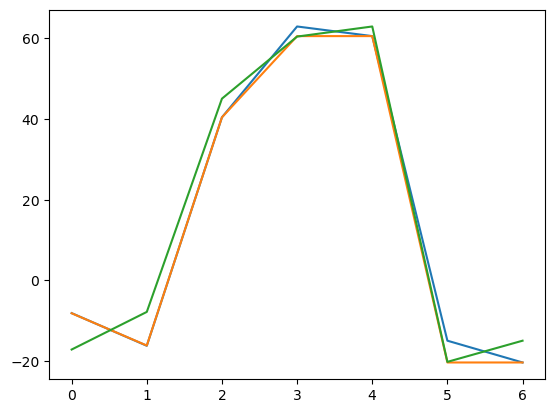

In [4]:
ind_ = np.where(rat2_dark['speed'] > 400)

plt.plot(rat2_dark['x'][ind_])
plt.plot(rat2_dark['x'][ind_[0]+1])
plt.plot(rat2_dark['x'][ind_[0]-1])

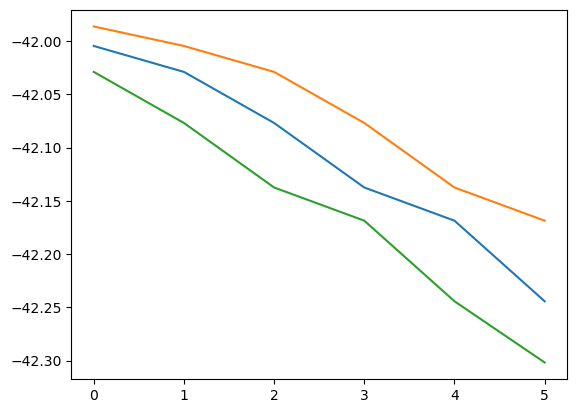

In [5]:
plt.plot(rat2_dark['x'][1:7])
plt.plot(rat2_dark['x'][0:6])
plt.plot(rat2_dark['x'][2:8])

(array([2.6844e+05, 7.4833e+04, 3.1150e+04, 8.4180e+03, 2.6020e+03,
        7.9300e+02, 1.9100e+02, 5.5000e+01, 1.0000e+01, 4.0000e+00,
        4.0000e+00, 1.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 130., 140., 150., 160., 170., 180., 190.]),
 <BarContainer object of 19 artists>)

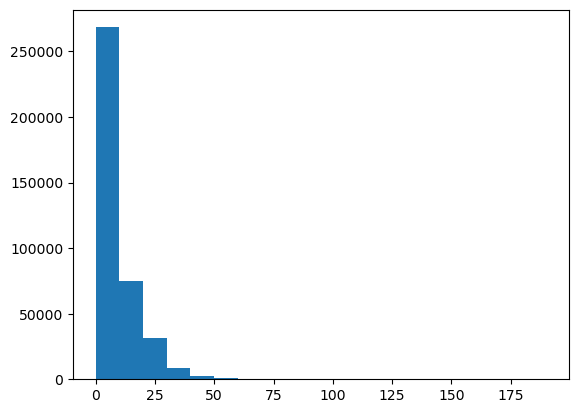

In [6]:
plt.hist(rat2_dark['speed'] , bins=np.arange(0 , 200 , 10 ) )

## Run gap sliding

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os , sys
from utils_kernel import KernelDecoder , TuningCurves

def opening_files(file_name, lighting = 'light'):
        dir_ = 'python_format'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat




rat_n = 2 #rat number
cond = 'dark' #dark or light
kernel_type = 'constsliding' #exp , const , gap_exp
direction ='future' #past, future
tau = 0.3 #Tau for exp kernel (s)
gap_mult = 2 # lenght of the gap for gap kernels, multipications of Tau_indicies



def mult_runs(rat_n , cond, kernel_type, direction , tau , gap_mult):
    if rat_n == 1:
            rat = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy', cond)
    if rat_n == 2:
            rat = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy', cond)
    if rat_n == 3:
            rat = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy', cond)
    if rat_n == 4:
            rat = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy', cond)
    if rat_n == 5:
            rat = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy', cond)



    loaded_dict = np.load(f'rat{rat_n}_{cond}_tc.npy', allow_pickle=True).item()
    kernel1 = KernelDecoder(rat_= rat, 
                            all_tc= loaded_dict,
                            kernel_type = kernel_type ,
                            filter_speed = False,
                            speed_threshold = 3, 
                            res = 0, 
                            Lim = 75, 
                            margin = 0, 
                            Rel_Tau = 10, 
                            Tau= tau)


    path = f'./rat{rat_n}_{cond}_{direction}_{kernel_type}_{tau}_{gap_mult}.csv'
    print("check param: s",path)

    errors_future = kernel1.decode_over_time_fix_window(gap_mult = gap_mult, time_indices=None , direction=direction  , path = path)


# for gap_mult in [2 ,3]:
gap_mult = 2
mult_runs(rat_n , cond, kernel_type, direction , tau , gap_mult)

check param: s ./rat2_dark_future_constsliding_0.3_2.csv


Decoding over time:   3%|▎         | 10923/386157 [05:22<3:04:44, 33.85it/s]


KeyboardInterrupt


## Shuffle

In [12]:
def opening_files(file_name, lighting = 'light'):
        dir_ = 'python_format'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat

In [64]:
            
rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy', 'dark')
rat2['grid_mod1'][644].shape

def randomize_spike_times(spike_times, t_min=None, t_max=None, seed=None):
    if seed is not None:
        np.random.seed(seed)
    t_min = np.min(spike_times)
    t_max = np.max(spike_times)
    randomized_spike_times = np.random.uniform(low=t_min, high=t_max, size=len(spike_times))
    return np.sort(randomized_spike_times)

# Example:
randomized_spikes = randomize_spike_times(rat2['grid_mod1'][644] , seed=200)

shuffle_mod1={}
for  key, array in rat2['grid_mod1'].items():
    shuffle_mod1[key] = randomize_spike_times(array , seed=200)

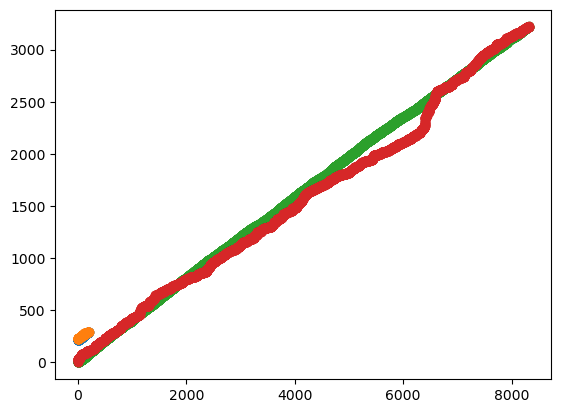

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import os


def opening_files(file_name, lighting = 'light'):
        dir_ = 'python_format'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat

def randomize_spike_times(spike_times, seed=200):
    # np.random.seed(seed)
    t_min = np.min(spike_times)
    t_max = np.max(spike_times)
    randomized_spike_times = np.random.uniform(low=t_min, high=t_max, size=len(spike_times))

    return np.sort(randomized_spike_times)


rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy', 'dark')

# shuffle_mod1={}
# for  key, array in rat2['grid_mod1'].items():
#     shuffle_mod1[key] = randomize_spike_times(array , seed=200)

# shuffle_mod2={}
# for  key, array in rat2['grid_mod2'].items():
#     shuffle_mod2[key] = randomize_spike_times(array , seed=200)

# shuffle_mod3={}
# for  key, array in rat2['grid_mod3'].items():
#     shuffle_mod3[key] = randomize_spike_times(array , seed=200)


# rat2['grid_mod1'] = shuffle_mod1
# rat2['grid_mod2'] = shuffle_mod2
# rat2['grid_mod3'] = shuffle_mod3

# np.savez('./rat2_rand.npz', **rat2)


random_spike = randomize_spike_times(rat2['grid_mod1'][644])
plt.scatter(np.arange(200),random_spike[500:700])
plt.scatter(np.arange(200),rat2['grid_mod1'][644][500:700])
plt.scatter(np.arange(len(random_spike)),random_spike)
plt.scatter(np.arange(len(rat2['grid_mod1'][644])),rat2['grid_mod1'][644])

In [105]:
rand_rat = np.load('rat2_rand_new.npz' , allow_pickle=True)
# list(rand_rat.keys())
# rand_rat['grid_mod1']
# rand_rat['x']

In [123]:
def find_k(array , value):
    return (np.abs(array-value)).argmin()
def rate_map(x, y, t, margin ,spike, bin_width= 1):
    x_edges = np.arange(min(x) - margin, max(x)+margin , bin_width)
    y_edges = np.arange(min(y) - margin, max(y)+margin , bin_width)
    ind_x = [find_k(t, i) for i in spike]
    ind_y = [find_k(t, i) for i in spike]

    occ = np.histogram2d(x, y, bins = (x_edges , y_edges))[0]
    act = np.histogram2d(x[ind_x], y[ind_y], bins = (x_edges , y_edges))[0]
    # rate = pad_rate_map(act) / (pad_rate_map(occ)*0.02)
    # return mask_outside_circle(rate)
    rate = act / (occ*0.02)
    rate = np.nan_to_num(rate)

    return rate
spikes_dict = rand_rat['grid_mod1'].item()  # Extract the dictionary from the 0-dim array
spikes = spikes_dict[695]
rm  = rate_map(x = rand_rat['x'] , y = rand_rat['y'] , t = rand_rat['t'] ,margin=0, spike=spikes)

/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1273/317002518.py:13: RuntimeWarning: invalid value encountered in divide
  rate = act / (occ*0.02)


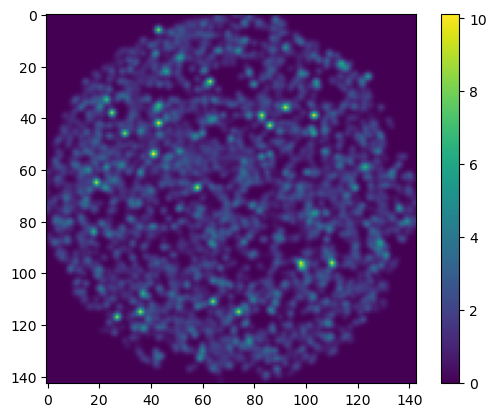

In [124]:
from scipy.ndimage import gaussian_filter, rotate
smoothed_rm =  gaussian_filter(rm, sigma=1, mode='constant', cval=0, truncate=2.5)  # mode and cval for consistency with matlab's conv2

plt.imshow(smoothed_rm)
plt.colorbar()

/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1273/317002518.py:13: RuntimeWarning: invalid value encountered in divide
  rate = act / (occ*0.02)


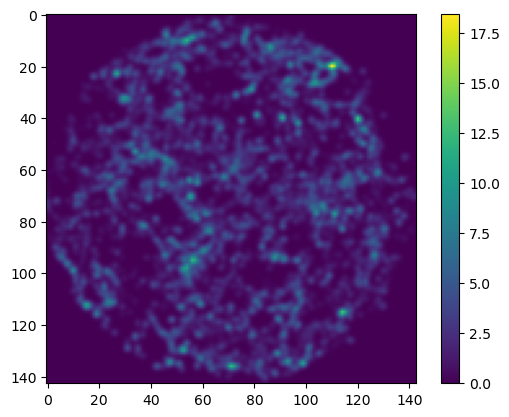

In [117]:
real_rm  = rate_map(x = rat2['x'] , y = rat2['y'] , t = rat2['t'] ,margin=0, spike=rat2['grid_mod1'][695])
smoothed_real =  gaussian_filter(real_rm, sigma=1, mode='constant', cval=0, truncate=2.5)  # mode and cval for consistency with matlab's conv2

plt.imshow(smoothed_real)
plt.colorbar()


## Fake rat

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os , sys
from utils_kernel import KernelDecoder , TuningCurves

fake2 = np.load('./fake_rat2_all.npz' , allow_pickle=True)

mod1 = fake2['grid_mod1']
mod2 = fake2['grid_mod2']
mod3 = fake2['grid_mod3']

# to get your original dict back:
grid_mod1_dict = mod1.item()
grid_mod2_dict = mod2.item()
grid_mod3_dict = mod3.item()

fake2_clean={'grid_mod1': grid_mod1_dict,
             'grid_mod2': grid_mod2_dict,
             'grid_mod3': grid_mod3_dict,
             't' : fake2['t'],
             'x' : fake2['x'],
             'y' : fake2['y'],
}


# run command for this script: python3 main.py 2 dark exp past
rat_n = 2 #rat number
cond = 'dark' #dark or light


tuning_curve = TuningCurves(rat_= fake2_clean,
                        filter_speed = False,
                        speed_threshold = 3,
                        res = 0,
                        Lim = 75,
                        margin = 0)
np.save(f'fakerat{rat_n}_{cond}_tc.npy' ,tuning_curve.tuning_curve )

Computing tuning curves for grid_mod1...


Tuning curves (grid_mod1):   0%|          | 0/68 [00:13<?, ?it/s]


KeyboardInterrupt: 

In [28]:
fake2['t']

array([0.00000000e+00, 8.02337770e-03, 1.65318541e-02, ...,
       1.95097254e+03, 1.95098060e+03, 1.95098936e+03])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os , sys
from utils_kernel import KernelDecoder , TuningCurves
fake2 = np.load('./fake_rat2_all.npz' , allow_pickle=True)

mod1 = fake2['grid_mod1']
mod2 = fake2['grid_mod2']
mod3 = fake2['grid_mod3']

# to get your original dict back:
grid_mod1_dict = mod1.item()
grid_mod2_dict = mod2.item()
grid_mod3_dict = mod3.item()

fake2_clean={'grid_mod1': grid_mod1_dict,
             'grid_mod2': grid_mod2_dict,
             'grid_mod3': grid_mod3_dict,
             't' : fake2['t'],
             'x' : fake2['x'],
             'y' : fake2['y'],
}



# run command for this script: python3 main.py 2 dark exp past tau
rat_n = int(sys.argv[1]) #rat number
cond = str(sys.argv[2]) #dark or light
kernel_type = sys.argv[3] #exp , const , gap_exp
direction = sys.argv[4] #past, future
tau = float(sys.argv[5]) #Tau for exp kernel (s)
gap_mult = 




# loaded_dict =  np.load(f'fakerat{rat_n}_{cond}_tc.npy', allow_pickle=True).item()
loaded_dict =  np.load(f'fakerat{rat_n}_{cond}_tc.npy', allow_pickle=True).item()


kernel1 = KernelDecoder(rat_= fake2_clean, 
                            all_tc= loaded_dict,
                            kernel_type = kernel_type ,
                            filter_speed = False,
                            speed_threshold = 3, 
                            res = 0, 
                            Lim = 75, 
                            margin = 0, 
                            Rel_Tau = 10, 
                            Tau= tau)


path = f'./fakerat{rat_n}_{cond}_{direction}_{kernel_type}_{tau}_{gap_mult}.csv'
print("check param: s",path)

errors_future = kernel1.decode_over_time_fix_window(gap_mult = gap_mult, time_indices=None , direction=direction  , path = path)


['t', 'x', 'y', 'grid_mod1', 'grid_mod2', 'grid_mod3']

## run

In [8]:
tuning_curve = TuningCurves(rat_= rat2_dark, 
                        filter_speed = False,
                        speed_threshold = 3, 
                        res = 0, 
                        Lim = 75,
                        margin = 0 , fold= 4 , cv = 4)

# np.save('rat2_dark_tc.npy' ,tuning_curve.tuning_curve )


Computing tuning curves for grid_mod1...


Tuning curves (grid_mod1):   0%|          | 0/41 [00:00<?, ?it/s]/Users/sara/Desktop/grid_decoding/utils_kernel.py:50: RuntimeWarning: invalid value encountered in divide
  rate = act / (occ*0.02)
Tuning curves (grid_mod1):   7%|▋         | 3/41 [00:16<03:28,  5.48s/it]


KeyboardInterrupt: 

In [21]:
for i in [1, 2, 3, 4]:
    tuning_curve = TuningCurves(rat_= rat2_dark, 
                            filter_speed = False,
                            speed_threshold = 3, 
                            res = 0, 
                            Lim = 75,
                            margin = 0 , cv_n= i , cv = 4)
    print(tuning_curve.t_start_mask , tuning_curve.t_end_mask)

1 96629 0
0.0 805.2444898899699
2 96629 96629
805.2444898899699 1610.496206859855
3 96629 193258
1610.496206859855 2415.772229162265
4 96629 289887
2415.772229162265 3220.990135826065


In [18]:
rat2_dark['t'][-1], len(rat2_dark['t'])/4

(np.float64(3220.990135826065), 96629.25)

In [7]:
loaded_dict = np.load('rat2_dark_tc.npy', allow_pickle=True).item()
kernel1 = KernelDecoder(rat_= rat2_dark, 
                        all_tc= loaded_dict,
                        kernel_type='constsliding',
                        filter_speed = False,
                        speed_threshold = 3, 
                        res = 0, 
                        Lim = 75, 
                        margin = 0, 
                        Rel_Tau = 10, 
                        Tau= 0.4)
# errors_future = kernel1.decode_over_time(time_indices=None , direction='future')


In [8]:
spikes_dict = kernel1.get_spikes(20, 0, 'grid_mod1')
kernel1.log_L_i(0 , 644 , spikes_dict , direction = 'past')

num_of_spikes [1 1 1 1]
Rel_times_arr [ -0.13333603  -0.22522377 -15.93241485 -19.96546424]
 self.Tau_indicies 48.0
kernel [0.00277783 0.00469216 0.33192531 0.41594717]


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [12]:
a = kernel1.decode_over_time_fix_window(gap_mult = 2, time_indices = np.arange(384 , 394) , direction = 'future' , path = './decodingaaa.csv' )

In [9]:
a = kernel1.decode_over_time_fix_window(gap_mult = 10, time_indices = np.arange(0 , 10) , direction = 'future' , path = './decodingaaa.csv' )

t1:  528.0 t2:  480.0 t0 0
t1:  529.0 t2:  481.0 t0 1
t1:  530.0 t2:  482.0 t0 2
t1:  531.0 t2:  483.0 t0 3
t1:  532.0 t2:  484.0 t0 4
t1:  533.0 t2:  485.0 t0 5
t1:  534.0 t2:  486.0 t0 6
t1:  535.0 t2:  487.0 t0 7
t1:  536.0 t2:  488.0 t0 8
t1:  537.0 t2:  489.0 t0 9


In [17]:
kernel1.Rel_times

np.float64(480.0)

In [10]:
a = kernel1.decode_over_time_fix_window(gap_mult = 5, time_indices = np.arange(480 , 490) , direction = 'past' , path = './decodingaaa.csv' )

t1:  192.0 t2:  240.0 t0 480
t1:  193.0 t2:  241.0 t0 481
t1:  194.0 t2:  242.0 t0 482
t1:  195.0 t2:  243.0 t0 483
t1:  196.0 t2:  244.0 t0 484
t1:  197.0 t2:  245.0 t0 485
t1:  198.0 t2:  246.0 t0 486
t1:  199.0 t2:  247.0 t0 487
t1:  200.0 t2:  248.0 t0 488
t1:  201.0 t2:  249.0 t0 489


In [4]:
kernel1.Tau_indicies , kernel1.dt

(np.float64(36.0), np.float64(0.008333394053094995))

In [4]:
errors_future = kernel1.decode_over_time_save_csv(time_indices= np.arange(21216.0 , 21220.0) , direction='future')

100%|██████████| 4/4 [00:00<00:00,  9.21it/s]

[[0.1, 'exp', 'future'], [np.float64(21218.0), 4, np.float64(5.7984142471194895), np.float64(-2443.208928758997), array([-84.12418717]), array([-23.96574137]), array([-58.34336278]), array([-8.41634158]), array([-16.2762157]), array([-22.50461091]), array([-8.31918697]), array([-82.91128167]), array([-8.25690228]), array([-57.94562554]), array([-16.17399244]), array([-9.15273117]), array([-24.30204049]), array([-16.19075816]), array([-73.30767375]), array([-27.35094414]), array([-24.37412377]), array([-130.63494404]), array([-71.33699263]), array([-77.52577472]), array([-49.20532322]), array([-16.52503969]), array([-8.79773411]), array([-22.467363]), array([-24.55661611]), array([-7.68167665]), array([-9.20372468]), array([-8.1948879]), array([-8.29648695]), array([-23.56345701]), array([-8.82813737]), array([-44.79045508]), array([-126.35172517]), array([-8.9455732]), array([-8.14610963]), array([-65.85059232]), array([-81.61172881]), array([-8.89600117]), array([-38.97802223]), array

In [14]:
kernel1.Rel_times

np.float64(120.0)

In [6]:
errors_future = kernel1.decode_over_time(time_indices= np.arange(258051.0 , kernel1.num_points - kernel1.Rel_times) , direction='future')

100%|██████████| 128346/128346 [4:20:23<00:00,  8.22it/s]     


In [ ]:
# with open('rat2_dark_future_10_part4.json' , 'w') as f:
#     json.dump(errors_future , f)

In [5]:
with open('rat2_dark_future_10.json' , 'r') as f:
    part1 = json.load(f)
with open('rat2_dark_future_10_part2.json' , 'r') as f:
    part2 = json.load(f)
with open('rat2_dark_future_10_part3.json' , 'r') as f:
    part3 = json.load(f)
with open('rat2_dark_future_10_part4.json' , 'r') as f:
    part4 = json.load(f)

In [6]:
all_errors_concat = part1
all_errors_concat.update(part2)
all_errors_concat.update(part3)
all_errors_concat.update(part4)

In [12]:
all_errors_concat

{'0.0': [7, 4.84450177663051, -1759.1195523939787],
 '1.0': [7, 6.293716917924346, -1759.04908386612],
 '2.0': [7, 4.761913918977774, -1705.8260311844426],
 '3.0': [7, 8.527177105577424, -1715.5127632710328],
 '4.0': [7, 6.718397486424157, -1695.534718331169],
 '5.0': [7, 7.994000069388488, -1672.2182084025228],
 '6.0': [7, 6.911278309161748, -1606.4417944502247],
 '7.0': [7, 6.705284549381436, -1580.7557349009242],
 '8.0': [6, 6.611097855421733, -1559.7256116498481],
 '9.0': [6, 3.8238818664297267, -1534.0833579649811],
 '10.0': [6, 5.997384009717059, -1531.9222013260337],
 '11.0': [6, 7.819207765433792, -1510.1726115370664],
 '12.0': [6, 3.7520310550056486, -1510.4543347733058],
 '13.0': [6, 6.0448034482772295, -1503.6450374120946],
 '14.0': [6, 7.995697713528334, -1496.0717828857453],
 '15.0': [6, 7.014990659422575, -1474.782394006001],
 '16.0': [6, 9.036701340852892, -1457.3538231924772],
 '17.0': [6, 9.677837693363983, -1458.4104081254068],
 '18.0': [6, 12.423977054139375, -1441.6

22.757860024792162 22.16069203308036


(array([27849., 45811., 30129., 19957., 16120., 12838., 10214.,  8110.,
         6579.,  6186.,  4427.,  4198.,  3126.,  2637.,  2654.]),
 array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.,
        65., 70., 75.]),
 <BarContainer object of 15 artists>)

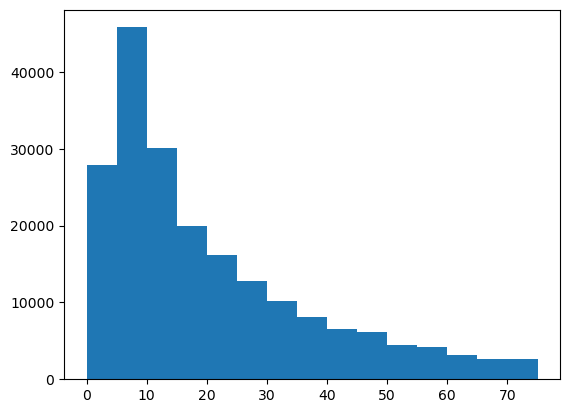

In [ ]:
errors = [all_errors_concat[k][0] for k in all_errors_concat.keys()  ]
print(np.mean(errors) , np.std(errors))
plt.hist(errors ,  bins=np.arange(0 , 80 , 5 ))

In [9]:
with open('rat2_dark_speed_treshhold.json' , 'r') as f:
    part1 = json.load(f)
with open('rat2_dark_speed_treshhold_part2.json' , 'r') as f:
    part2 = json.load(f)
with open('rat2_dark_speed_treshhold_part3.json' , 'r') as f:
    part3 = json.load(f)


In [10]:
all_errors_concat_past = part1
all_errors_concat_past.update(part2)
all_errors_concat_past.update(part3)
all_errors_concat_past.update(part4)

23.63759981507091 22.454467257573853


(array([30043., 51388., 35052., 24475., 19685., 16125., 12373.,  9914.,
         8501.,  7661.,  5598.,  5129.,  3800.,  3304.,  3335.]),
 array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.,
        65., 70., 75.]),
 <BarContainer object of 15 artists>)

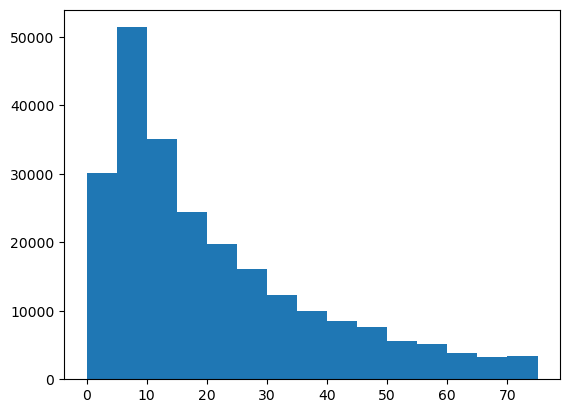

In [11]:
errors_past = [all_errors_concat_past[k][0] for k in all_errors_concat_past.keys()]
print(np.mean(errors_past) , np.std(errors_past))
plt.hist(errors_past ,  bins=np.arange(0 , 80 , 5 ))